In [2]:
import numpy as np
from qubicpack.qubicfp import qubicfp
import sys,os
import glob

import matplotlib.pyplot as plt
import matplotlib.mlab as mlab

In [3]:
day = '2023-05-28'
data_dir = '/home/qubic/Calib-TD/'+day+'/'
words = ['DomeOpened']
keywords = ['*{}*'.format(word) for word in words]
for keyword in keywords:
    dirs = np.sort(glob.glob(data_dir+keyword))
    print(dirs)

['/home/qubic/Calib-TD/2023-05-28/2023-05-28_05.52.59__SkyDips-2.5V-DomeOpened-Night'
 '/home/qubic/Calib-TD/2023-05-28/2023-05-28_12.32.03__SkyScan-2.25V-DomeOpened'
 '/home/qubic/Calib-TD/2023-05-28/2023-05-28_16.24.20__SkyScan-2.75V-DomeOpened']


In [4]:
data_path = "/home/belen/Doctorado/qubic-dev/qubic/qubic/data/Flux_jumps/"
soft_path = "/home/belen/Doctorado/qubic-dev/qubic/qubic/lib/Calibration/"
dict_path = "/home/belen/Doctorado/qubic-dev/qubic/qubic/dicts/"
sys.path.append(os.path.abspath(soft_path))

In [5]:
import Qfluxjumps as jr
import Qsaturation as qsat

## 05.52.59 skydip 2.5V 

In [5]:
dataset0 = dirs[0]
a = qubicfp()
a.read_qubicstudio_dataset(dataset0)

ASIC1     Observation date: 2023-05-28 05:52:59.602000
ASIC1 Observation end date: 2023-05-28 07:10:32.878000
ASIC2     Observation date: 2023-05-28 05:52:59.600000
ASIC2 Observation end date: 2023-05-28 07:10:32.878000
No MMR data found in directory: /home/qubic/Calib-TD/2023-05-28/2023-05-28_05.52.59__SkyDips-2.5V-DomeOpened-Night/Hks
No MGC data found in directory: /home/qubic/Calib-TD/2023-05-28/2023-05-28_05.52.59__SkyDips-2.5V-DomeOpened-Night/Hks
No hornswitch data found in directory: /home/qubic/Calib-TD/hornswitch
Please give a valid asic number
No previously saved filter information: QUBIC_TES_ASIC1_20230528T055259UTC.filter.pickle
No previously saved filter information: QUBIC_TES_ASIC2_20230528T055259UTC.filter.pickle
Not a valid housekeeping ID: MMR_HK
Not a valid housekeeping ID: MGC_HK
Not a valid housekeeping ID: TES STAGE
Please give an asic number
Please enter a valid ASIC or TES number
WARNING!  Bath temperature is unknown!
ERROR! Temperature should be a number in Kel

True

In [6]:
tod = a.tod()
timeaxis = tod[0]
todarray = tod[1]
init = timeaxis[0]
tt = timeaxis - init

print('number of timesamples along every TES in this dataset:', np.shape(todarray[0,:]))

suggest nsamples=729088 which is  2^13*89
number of timesamples along every TES in this dataset: (729088,)


In [6]:
tt[-1]/60

77.55704666376114

In [7]:
# TES_yes: idx TES with flux jumps found by haar filter
# TES_no: idx TES with no flux jumps found
# TES_yes_dt: refinament of idx TES with flux jumps using DT (could be equal to TES_yes)
# jump_data: "idx", xc", "xcf", "nc"
# dt_jump_data: "idx", "xcdt", "xcfdt", "ncdt"
# corrected data no dt: idx and TES corrected without DT 
# offset no dt: amplitudes of jumps without DT
# corrected data dt: idx and TES corrected with DT 
# offset dt: amplitudes of jumps with DT
# metrics no dt: metrics without DT 
# metrics dt: metrics with DT

results = {
    'TES_yes': [],
    'TES_no': [],
    'TES_yes_dt': [],
    'jump_data': {},
    'dt_jump_data': {},
    'corrected_data_nodt': {},
    'offset_nodt': {},
    'corrected_data_dt': {},
    'offset_dt': {},
    'metrics_nodt': {}, 
    'metrics_dt':{}
    }

In [8]:
sat = qsat.saturation(sat_value=4.19e6, TES_number=256) 
sat_mask, sat_idx, sat_frac, n_sat = sat.detect_saturation(todarray)

#IV class. You have to load the directory and the filename of the IV analysis
#IVdict2025.yaml or IVdict2023.yaml are the dicts with the IV information from 2025 and 2022-2023
iv = jr.badIV(directory=dict_path, n_times=10, TES_number=256, filename="IVdict2023.yaml") 
iv_mask = iv.select_badIV()

good_mask = sat_mask & iv_mask        # Create a mask with both saturation and bad IV
good_idx  = np.where(good_mask)[0]    # index of TES with good IV and no saturation
good_tod  = todarray[good_mask, :]    # TOD of good TES

print(good_idx)

[  2   3   4   5   7   8   9  13  14  15  19  21  22  24  25  26  27  28
  30  31  32  33  35  36  37  38  39  41  43  45  49  53  54  57  58  59
  60  61  62  63  65  66  67  68  69  70  71  72  75  77  80  81  84  85
  86  87  88  89  90  91  92  93  94  95  97  98 100 102 105 108 110 111
 112 116 121 128 129 130 131 132 133 134 135 136 139 141 142 144 145 146
 147 148 149 151 152 155 157 158 159 160 161 162 163 166 167 168 169 170
 171 172 173 174 175 177 178 179 180 181 182 183 184 185 186 187 188 192
 193 194 195 196 197 198 199 200 201 202 204 205 206 207 208 209 211 212
 213 214 216 217 219 220 222 223 224 231 232 234 235 238 239 241 243 245
 246 247 248 251 254 255]


In [9]:
thr = 2.5e5 # Multiple thresholds for better detection
window_size = 500  # Optimized for this dataset length
fluxjumps = jr.fluxjumps(thr=thr, window_size=window_size)

In [10]:
jump_data = {}
for idx_good in good_idx:
    nc, xc, xcf = fluxjumps.jumps_detection(
        todarray[idx_good], 
        consec=True,   # Merge consecutive jumps
        nc_cond=True  # Re-threshold if too many jumps
    )
    jump_data[idx_good] = {'nc': nc, 'xc': xc, 'xcf': xcf}


In [11]:
# Classify TES
TES_yes = [idx for idx in good_idx if jump_data[idx]['nc'] > 0]
TES_no = [idx for idx in good_idx if jump_data[idx]['nc'] == 0]

In [12]:
results['TES_yes'] = TES_yes
results['TES_no'] = TES_no
results['jump_data'] = jump_data

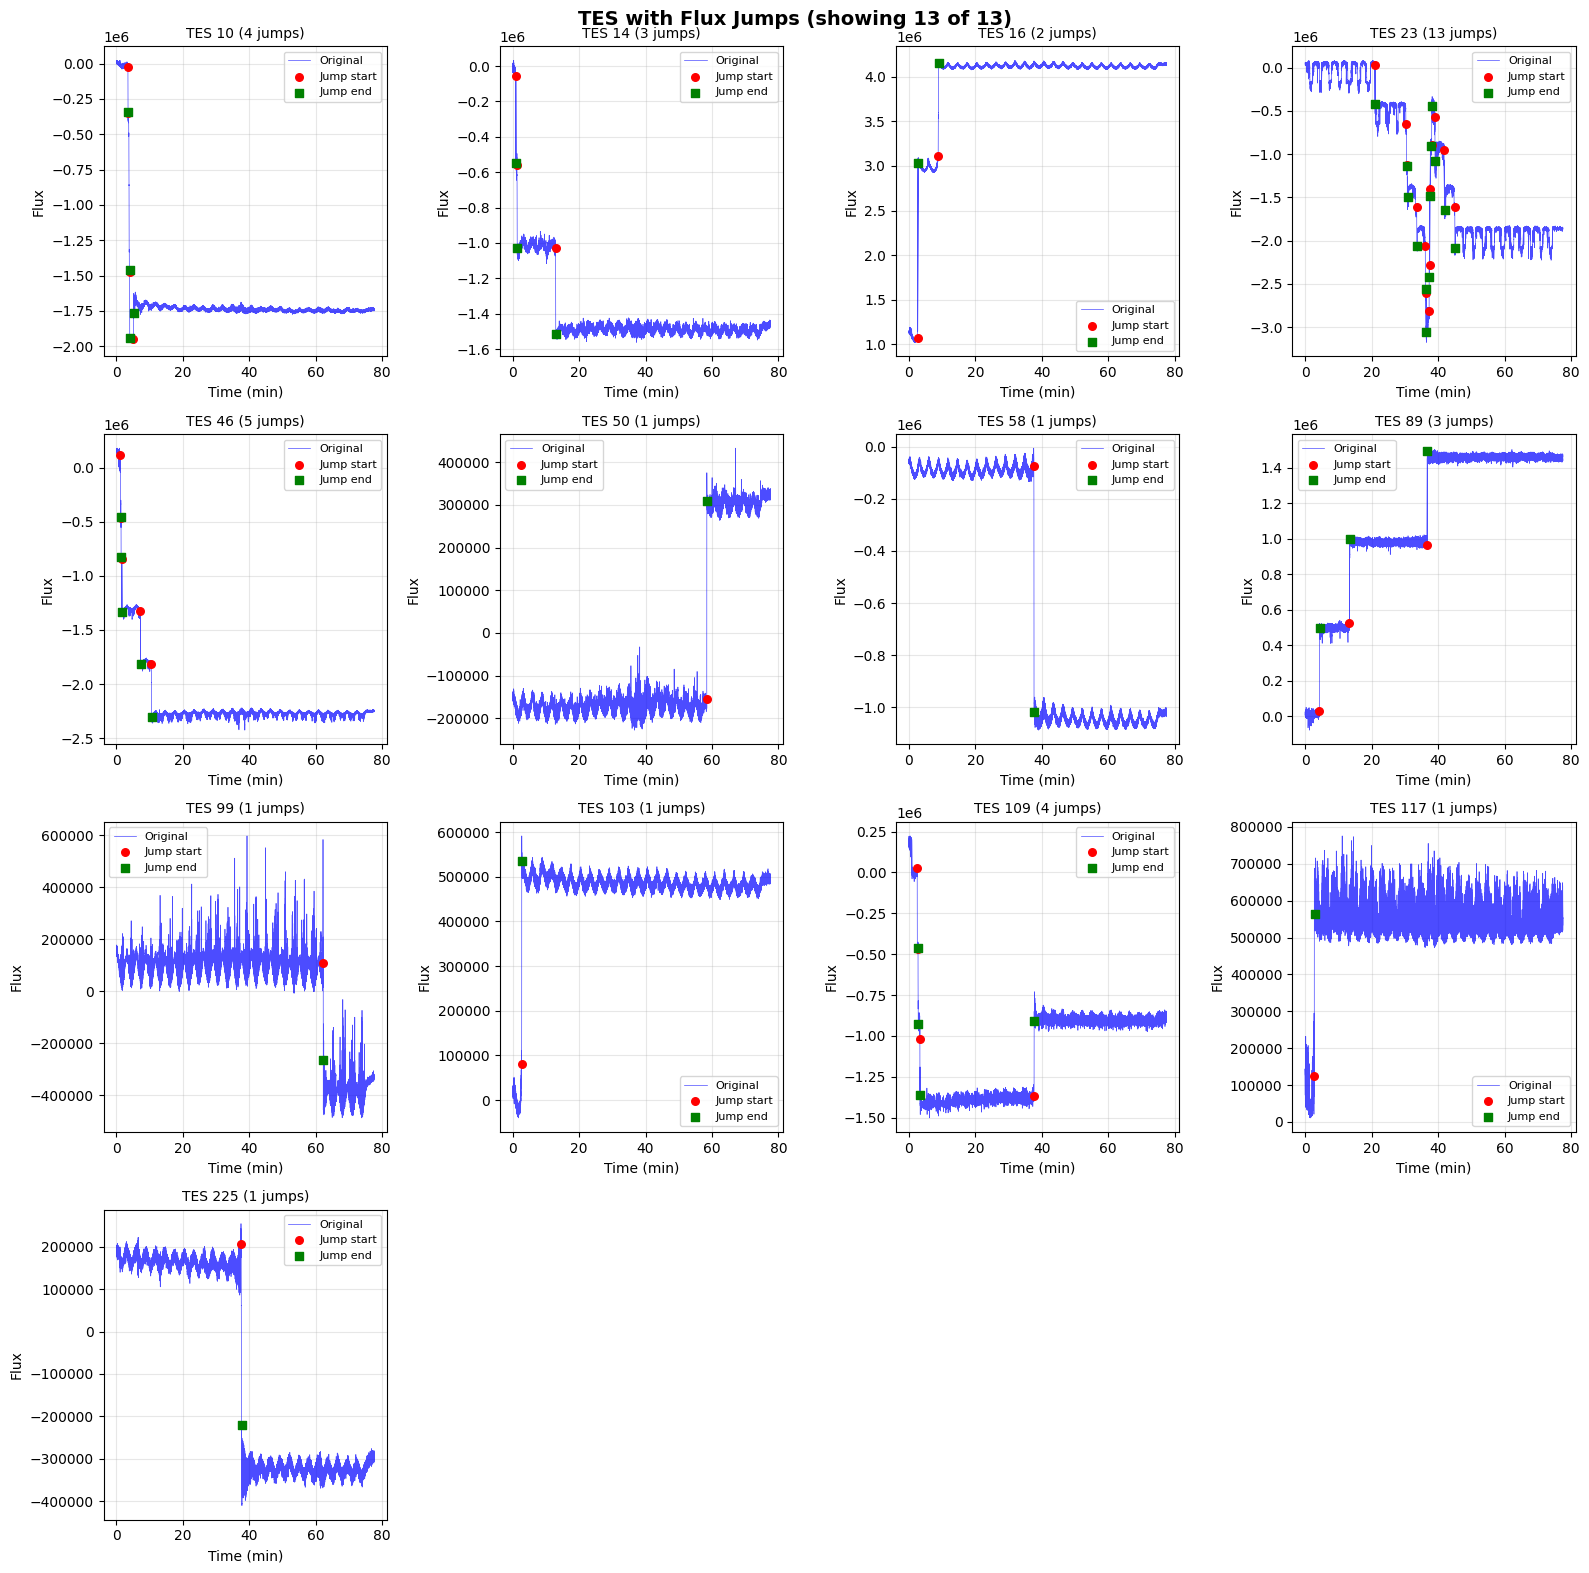

0

In [23]:
jr.plot_jump_detections(tt, todarray, results, DT=False)

In [13]:
# Step 2: Decision Tree Refinement
dt = jr.DT(thr_count=2e3, thr_amp=2.6e5, tol=1e2, depth=True)
dt_jump_data = {}
TES_with_dt_jumps = []
for idx in TES_yes:
    nc = jump_data[idx]['nc']
    xcdt, xcfdt = dt.calculate_levels(tt, todarray[idx], nc, consec=True)
    dt_jump_data[idx] = {'xcdt': xcdt, 'xcfdt': xcfdt, 'ncdt': len(xcdt)}
    if len(xcdt) > 0:
        TES_with_dt_jumps.append(idx)

In [14]:
results['dt_jump_data'] = dt_jump_data
results['TES_yes_dt'] = TES_with_dt_jumps

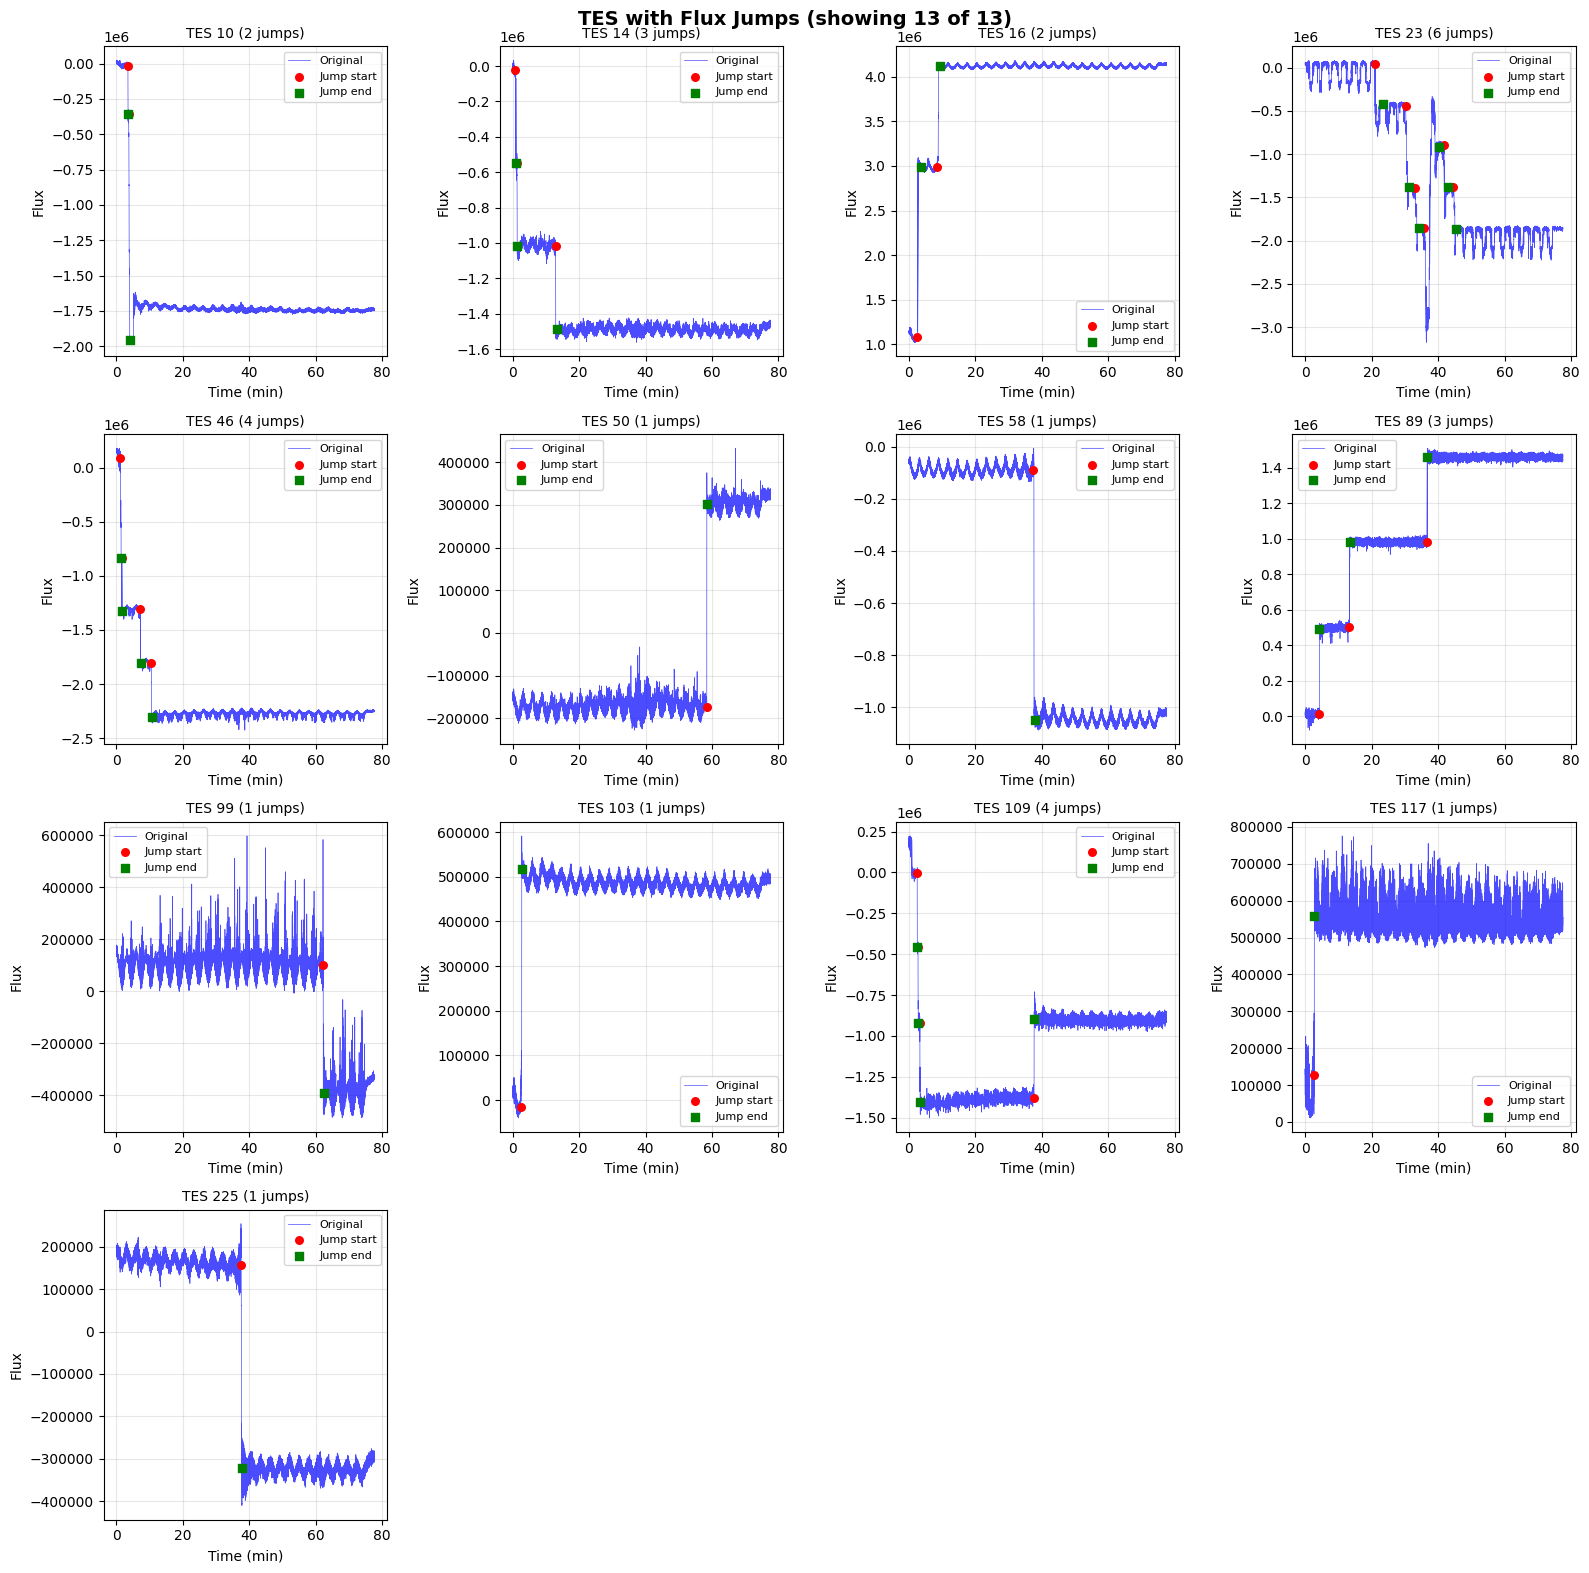

0

In [40]:
jr.plot_jump_detections(tt, todarray, results, DT=True)

In [15]:
corr = jr.correction(region_off=5, region_amp=3, change_mode="const")
corrected_tod = {}
offset = {}
for idx in TES_yes:
    if idx in dt_jump_data:
        xcdt = dt_jump_data[idx]['xcdt']
        xcfdt = dt_jump_data[idx]['xcfdt']
        nc_dt = dt_jump_data[idx]['ncdt']
        if nc_dt > 0:
            offset[idx] = corr.calculate_amplitude(todarray[idx], xcdt, xcfdt, nc_dt)
            corrected_tod[idx] = corr.correct_TOD(todarray[idx], offset[idx], xcdt, xcfdt, nc_dt)

In [16]:
corrected_tod_nodt = {}
offset_nodt = {}
for idx in TES_yes:
    if idx in jump_data:
        xc = jump_data[idx]['xc']
        xcf = jump_data[idx]['xcf']
        nc = jump_data[idx]['nc']
        if nc > 0:
            offset_nodt[idx] = corr.calculate_amplitude(todarray[idx], xc, xcf, nc)
            corrected_tod_nodt[idx] = corr.correct_TOD(todarray[idx], offset_nodt[idx], xc, xcf, nc)

In [17]:
results['corrected_data_dt'] = corrected_tod
results['offset_dt'] = offset

results['corrected_data_nodt'] = corrected_tod_nodt
results['offset_nodt'] = offset_nodt

In [28]:
metrics_dt, global_rms_dt = jr.compute_residual_metrics_from_results(
    results, todarray, window=4000, robust=False, use_dt=True, use_corrected=True
)

# without DT
metrics_haar, global_rms_haar = jr.compute_residual_metrics_from_results(
    results, todarray, window=4000, robust=False, use_dt=False, use_corrected=True
)

In [29]:
for i in TES_with_dt_jumps:
    print("TES:", i, np.mean(np.abs(metrics_haar[i]['z_scores']))/np.mean(np.abs(metrics_dt[i]['z_scores'])))

TES: 9 2.3593385470584542
TES: 13 1.087721461233769
TES: 15 0.9379385615182753
TES: 22 1.8590802944275633
TES: 45 2.5795710498264133
TES: 49 0.8834143116334416
TES: 57 0.488795627558423
TES: 88 14.873393314458724
TES: 98 3.5394368702311745
TES: 102 2.396458036612651
TES: 108 3.0735141221612734
TES: 116 0.9590203315648128
TES: 224 4.442318184618134


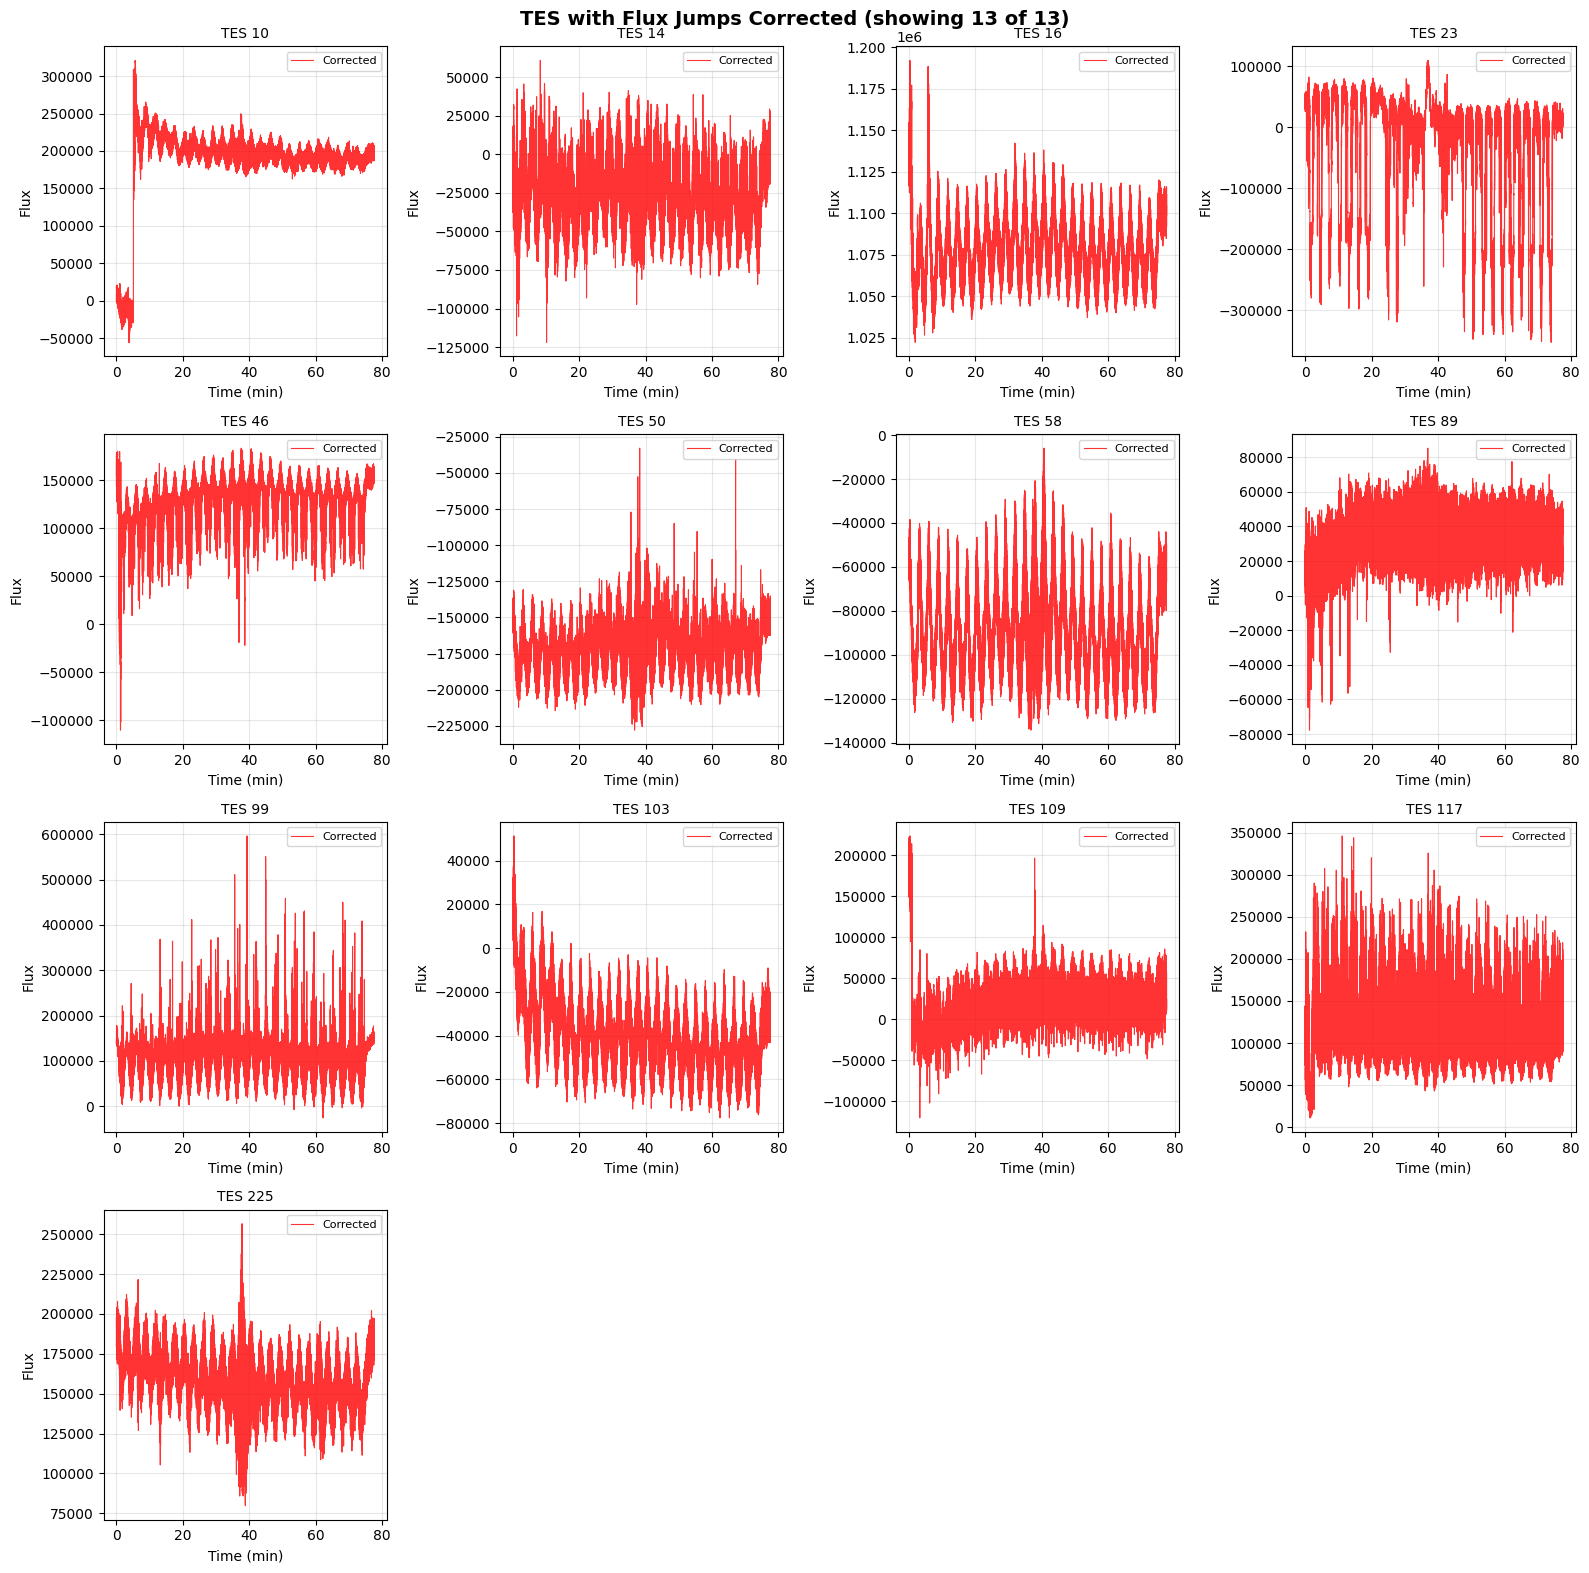

0

In [43]:
jr.plot_corrections(tt, todarray, results)

In [30]:
results['metrics_nodt'] = metrics_haar
results['metrics_dt'] = metrics_dt

In [31]:
jr.save_results(results, output_dir=data_path + "year_23_day_2805_05.52.59", dataset_name="23_2805_05.52.59")

Saved pickle file to: /home/belen/Doctorado/qubic-dev/qubic/qubic/data/Flux_jumps/year_23_day_2805_05.52.59/23_2805_05.52.59_results.pkl

All results saved to: /home/belen/Doctorado/qubic-dev/qubic/qubic/data/Flux_jumps/year_23_day_2805_05.52.59
Total files saved: 1



['/home/belen/Doctorado/qubic-dev/qubic/qubic/data/Flux_jumps/year_23_day_2805_05.52.59/23_2805_05.52.59_results.pkl']

In [6]:
dirs[2]

'/home/qubic/Calib-TD/2023-05-28/2023-05-28_16.24.20__SkyScan-2.75V-DomeOpened'

## skyscan 16.24.20 2.75V

In [5]:
dataset0 = dirs[2]
a2 = qubicfp()
a2.read_qubicstudio_dataset(dataset0)

ASIC1     Observation date: 2023-05-28 16:24:20.379000
ASIC1 Observation end date: 2023-05-28 19:58:47.894000
ASIC1     Observation date: 2023-05-28 16:24:20.379000
ASIC1 Observation end date: 2023-05-28 20:08:13.736000
ASIC2     Observation date: 2023-05-28 16:24:20.368000
ASIC2 Observation end date: 2023-05-28 19:58:47.893000
ASIC2     Observation date: 2023-05-28 16:24:20.368000
ASIC2 Observation end date: 2023-05-28 20:08:13.736000
No MMR data found in directory: /home/qubic/Calib-TD/2023-05-28/2023-05-28_16.24.20__SkyScan-2.75V-DomeOpened/Hks
No MGC data found in directory: /home/qubic/Calib-TD/2023-05-28/2023-05-28_16.24.20__SkyScan-2.75V-DomeOpened/Hks
No hornswitch data found in directory: /home/qubic/Calib-TD/hornswitch
Please give a valid asic number
No previously saved filter information: QUBIC_TES_ASIC1_20230528T162420UTC.filter.pickle
No previously saved filter information: QUBIC_TES_ASIC2_20230528T162420UTC.filter.pickle
Not a valid housekeeping ID: MMR_HK
Not a valid hou

True

In [6]:
tod = a2.tod()
timeaxis = tod[0]
todarray = tod[1]
init = timeaxis[0]
tt = timeaxis - init

print('number of timesamples along every TES in this dataset:', np.shape(todarray[0,:])) 

suggest nsamples=2113536 which is  2^14*3*43
number of timesamples along every TES in this dataset: (2113536,)


In [6]:
tt[-1]/60/60

3.731512388851908

In [7]:
# TES_yes: idx TES with flux jumps found by haar filter
# TES_no: idx TES with no flux jumps found
# TES_yes_dt: refinament of idx TES with flux jumps using DT (could be equal to TES_yes)
# jump_data: "idx", xc", "xcf", "nc"
# dt_jump_data: "idx", "xcdt", "xcfdt", "ncdt"
# corrected data no dt: idx and TES corrected without DT 
# offset no dt: amplitudes of jumps without DT
# corrected data dt: idx and TES corrected with DT 
# offset dt: amplitudes of jumps with DT
# metrics no dt: metrics without DT 
# metrics dt: metrics with DT

results = {
    'TES_yes': [],
    'TES_no': [],
    'TES_yes_dt': [],
    'jump_data': {},
    'dt_jump_data': {},
    'corrected_data_nodt': {},
    'offset_nodt': {},
    'corrected_data_dt': {},
    'offset_dt': {},
    'metrics_nodt': {}, 
    'metrics_dt':{}
    }

In [8]:
sat = qsat.saturation(sat_value=4.19e6, TES_number=256) 
sat_mask, sat_idx, sat_frac, n_sat = sat.detect_saturation(todarray)

#IV class. You have to load the directory and the filename of the IV analysis
#IVdict2025.yaml or IVdict2023.yaml are the dicts with the IV information from 2025 and 2022-2023
iv = jr.badIV(directory=dict_path, n_times=10, TES_number=256, filename="IVdict2023.yaml") 
iv_mask = iv.select_badIV()

good_mask = sat_mask & iv_mask        # Create a mask with both saturation and bad IV
good_idx  = np.where(good_mask)[0]    # index of TES with good IV and no saturation
good_tod  = todarray[good_mask, :]    # TOD of good TES

print(good_idx)

[  2   3   4   5   6   7   8   9  13  14  15  18  21  22  24  25  26  27
  28  30  31  32  33  35  36  37  38  39  40  41  43  45  49  50  53  57
  58  59  60  61  62  63  65  66  67  68  69  70  71  72  75  77  79  80
  81  83  84  85  86  87  88  89  90  91  92  93  94  95  97  98 100 102
 103 104 105 106 108 109 111 112 120 121 123 128 129 130 131 132 133 134
 135 136 137 139 140 141 142 144 145 146 147 148 149 151 152 155 157 158
 160 161 162 163 166 167 169 171 172 173 174 175 177 179 180 181 182 184
 185 186 187 188 192 193 194 195 196 197 198 199 200 201 202 204 205 206
 207 208 209 210 212 213 214 215 216 217 219 220 222 223 224 231 235 236
 238 241 243 244 245 251 254 255]


In [9]:
thr = 3e5  # Multiple thresholds for better detection
window_size = 500  # Optimized for this dataset length
fluxjumps = jr.fluxjumps(thr=thr, window_size=window_size)

In [11]:
jump_data = {}
for idx_good in good_idx:
    nc, xc, xcf = fluxjumps.jumps_detection(
        todarray[idx_good], 
        consec=True,   # Merge consecutive jumps
        nc_cond=True  # Re-threshold if too many jumps
    )
    jump_data[idx_good] = {'nc': nc, 'xc': xc, 'xcf': xcf}


In [12]:
# Classify TES
TES_yes = [idx for idx in good_idx if jump_data[idx]['nc'] > 0]
TES_no = [idx for idx in good_idx if jump_data[idx]['nc'] == 0]

In [13]:
results['TES_yes'] = TES_yes
results['TES_no'] = TES_no
results['jump_data'] = jump_data

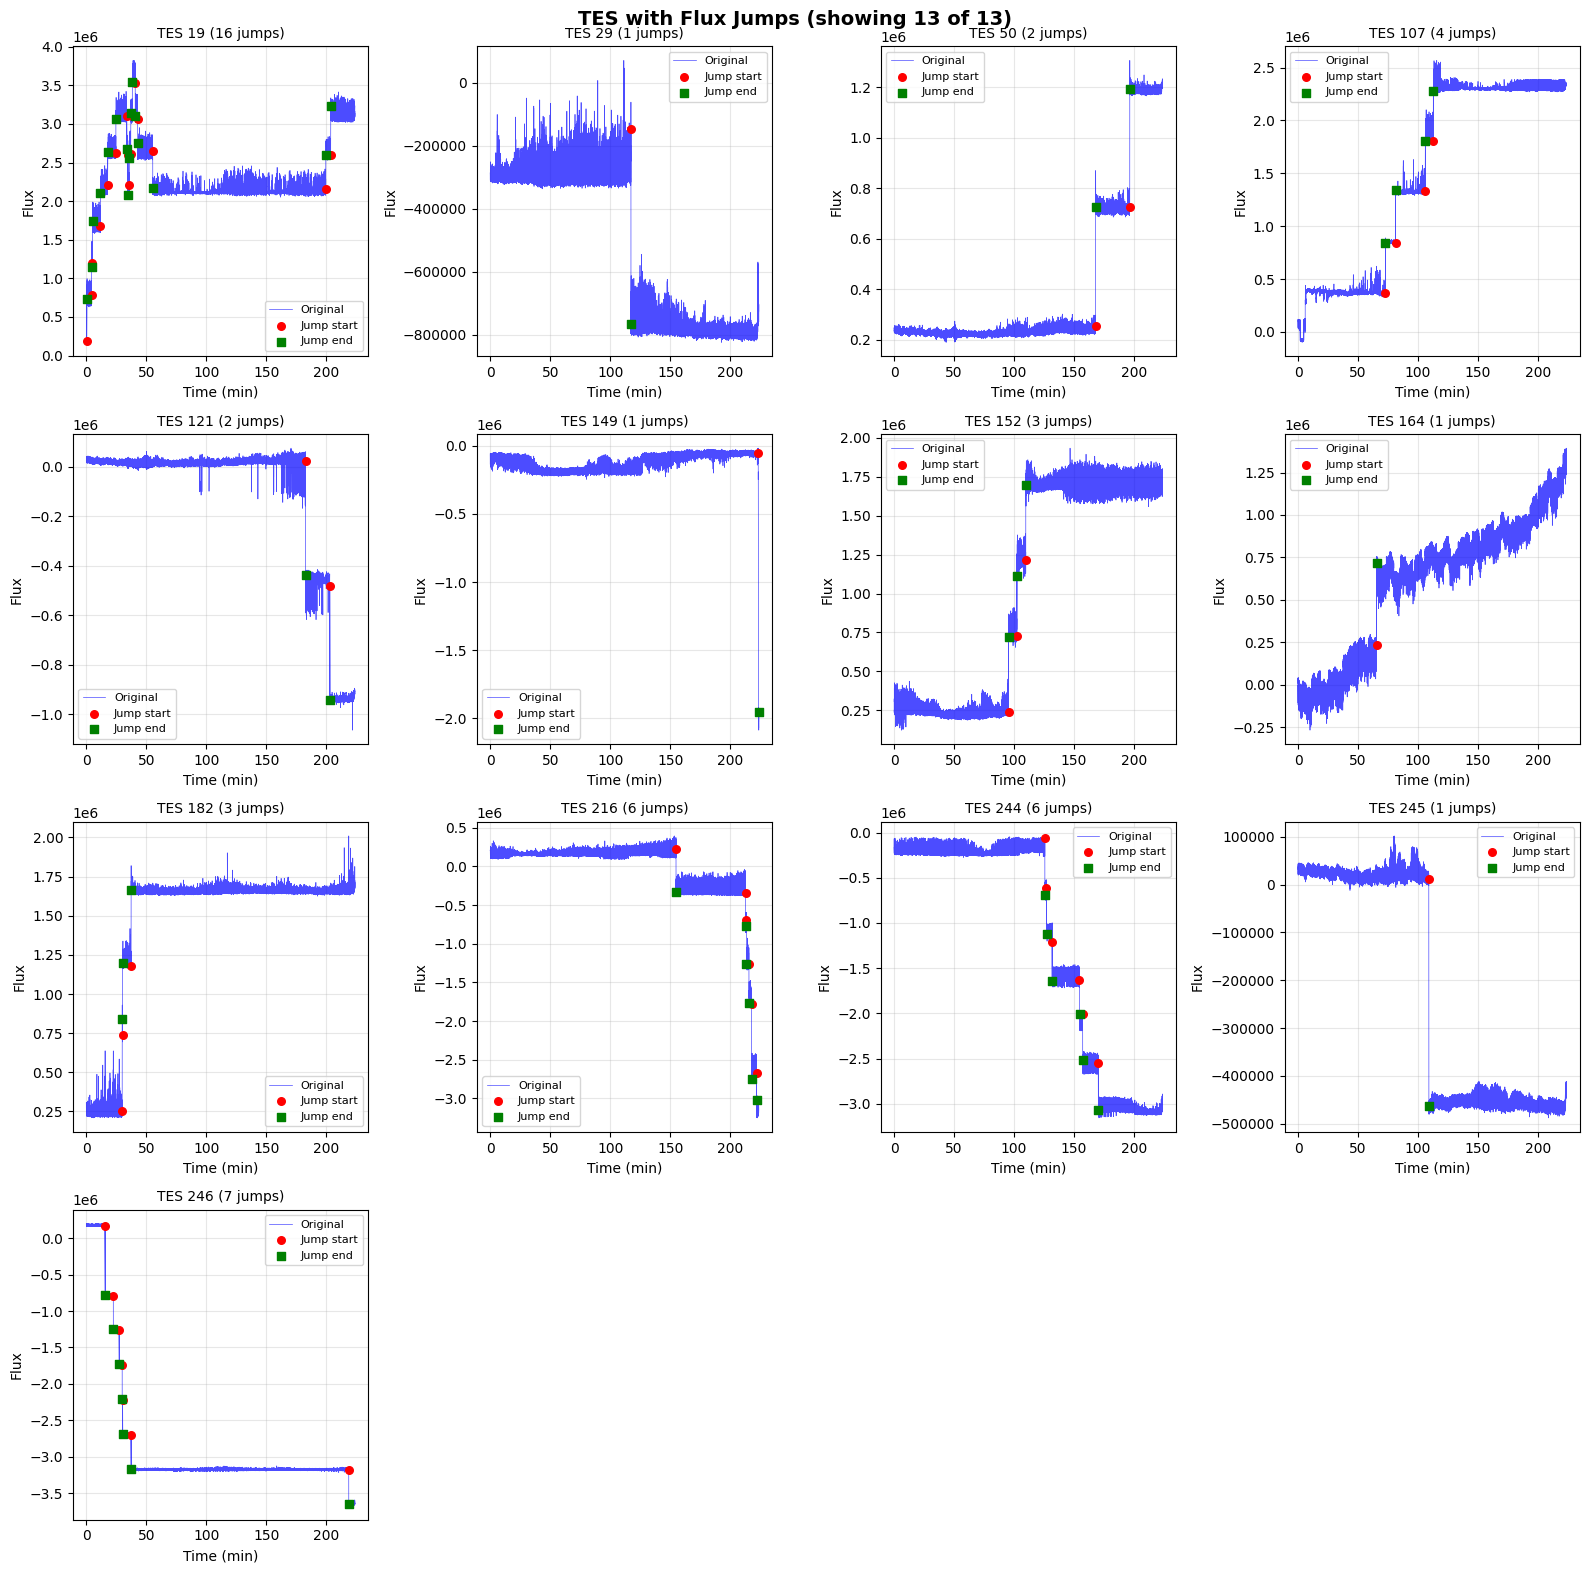

0

In [13]:
jr.plot_jump_detections(tt, todarray, results, DT=False)

In [14]:
# Step 2: Decision Tree Refinement
dt = jr.DT(thr_count=1e3, thr_amp=2e5, tol=1e2, depth=True)
dt_jump_data = {}
TES_with_dt_jumps = []
for idx in TES_yes:
    nc = jump_data[idx]['nc']
    xcdt, xcfdt = dt.calculate_levels(tt, todarray[idx], nc, consec=True)
    dt_jump_data[idx] = {'xcdt': xcdt, 'xcfdt': xcfdt, 'ncdt': len(xcdt)}
    if len(xcdt) > 0:
        TES_with_dt_jumps.append(idx)

In [15]:
results['dt_jump_data'] = dt_jump_data
results['TES_yes_dt'] = TES_with_dt_jumps

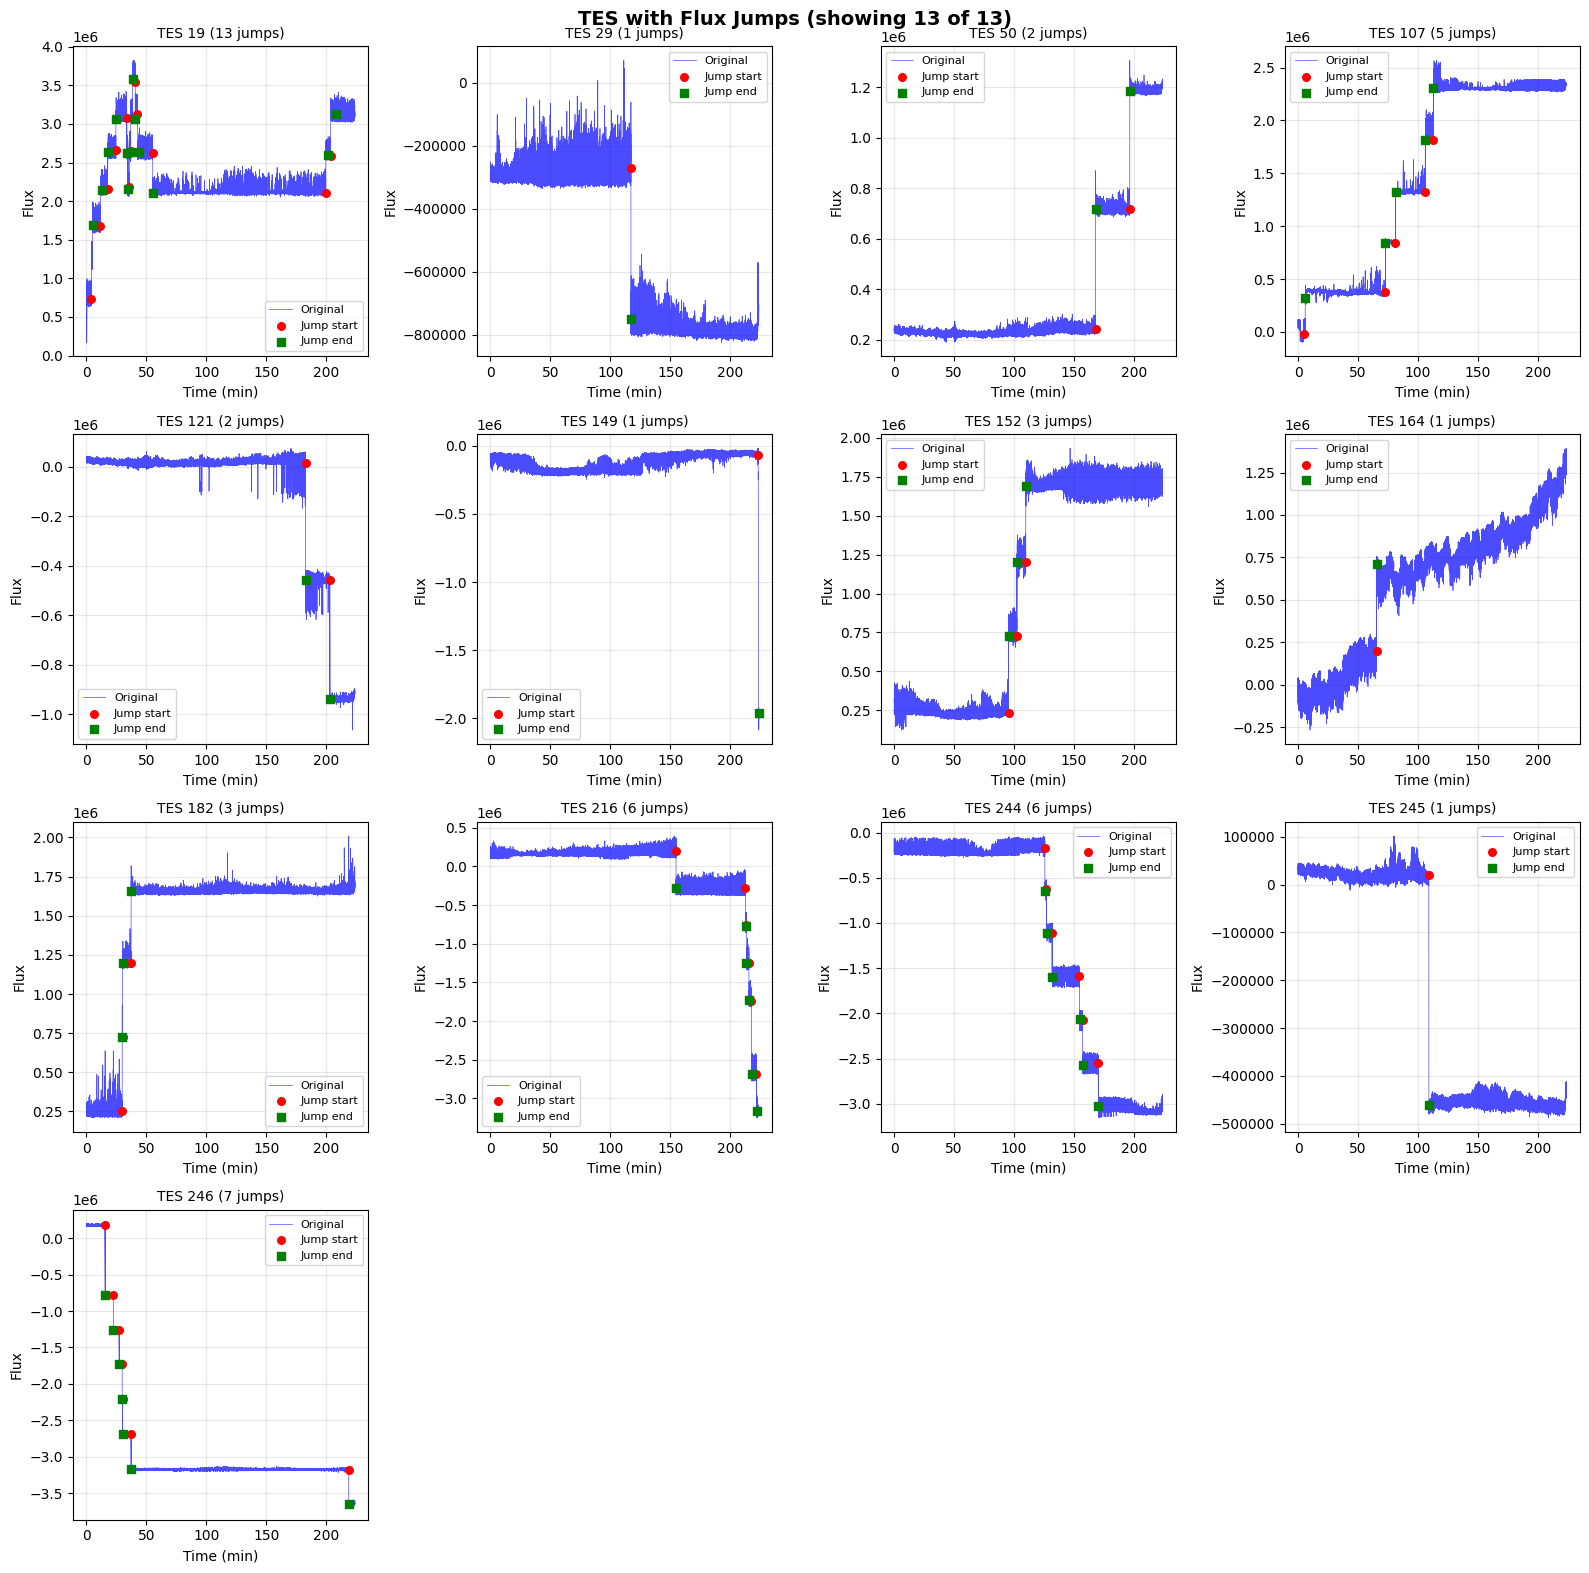

0

In [18]:
jr.plot_jump_detections(tt, todarray, results, DT=True)

In [17]:
corr = jr.correction(region_off=5, region_amp=3, change_mode="const")
corrected_tod = {}
offset = {}
for idx in TES_yes:
    if idx in dt_jump_data:
        xcdt = dt_jump_data[idx]['xcdt']
        xcfdt = dt_jump_data[idx]['xcfdt']
        nc_dt = dt_jump_data[idx]['ncdt']
        if nc_dt > 0:
            offset[idx] = corr.calculate_amplitude(todarray[idx], xcdt, xcfdt, nc_dt)
            corrected_tod[idx] = corr.correct_TOD(todarray[idx], offset[idx], xcdt, xcfdt, nc_dt)

In [18]:
corrected_tod_nodt = {}
offset_nodt = {}
for idx in TES_yes:
    if idx in jump_data:
        xc = jump_data[idx]['xc']
        xcf = jump_data[idx]['xcf']
        nc = jump_data[idx]['nc']
        if nc > 0:
            offset_nodt[idx] = corr.calculate_amplitude(todarray[idx], xc, xcf, nc)
            corrected_tod_nodt[idx] = corr.correct_TOD(todarray[idx], offset_nodt[idx], xc, xcf, nc)

In [19]:
results['corrected_data_dt'] = corrected_tod
results['offset_dt'] = offset

results['corrected_data_nodt'] = corrected_tod_nodt
results['offset_nodt'] = offset_nodt

In [26]:
metrics_dt, global_rms_dt = jr.compute_residual_metrics_from_results(
    results, todarray, window=1000, robust=False, use_dt=True, use_corrected=True
)

# without DT
metrics_haar, global_rms_haar = jr.compute_residual_metrics_from_results(
    results, todarray, window=1000, robust=False, use_dt=False, use_corrected=True
)

In [27]:
results['metrics_nodt'] = metrics_haar
results['metrics_dt'] = metrics_dt

In [28]:
for i in TES_with_dt_jumps:
    print("TES:", i, np.mean(np.abs(metrics_haar[i]['z_scores']))/np.mean(np.abs(metrics_dt[i]['z_scores'])))

TES: 18 2.3226081012040543
TES: 28 49.00238739727873
TES: 49 0.47915364863389004
TES: 106 0.6564294667373867
TES: 120 5.04149698584636
TES: 148 nan
TES: 151 0.8582797253312002
TES: 163 0.11734491605053654
TES: 181 6.049107036096084
TES: 215 2.932411011963064
TES: 243 3.1662178746204273
TES: 244 1.2956113969784973
TES: 245 1.1246691093026655


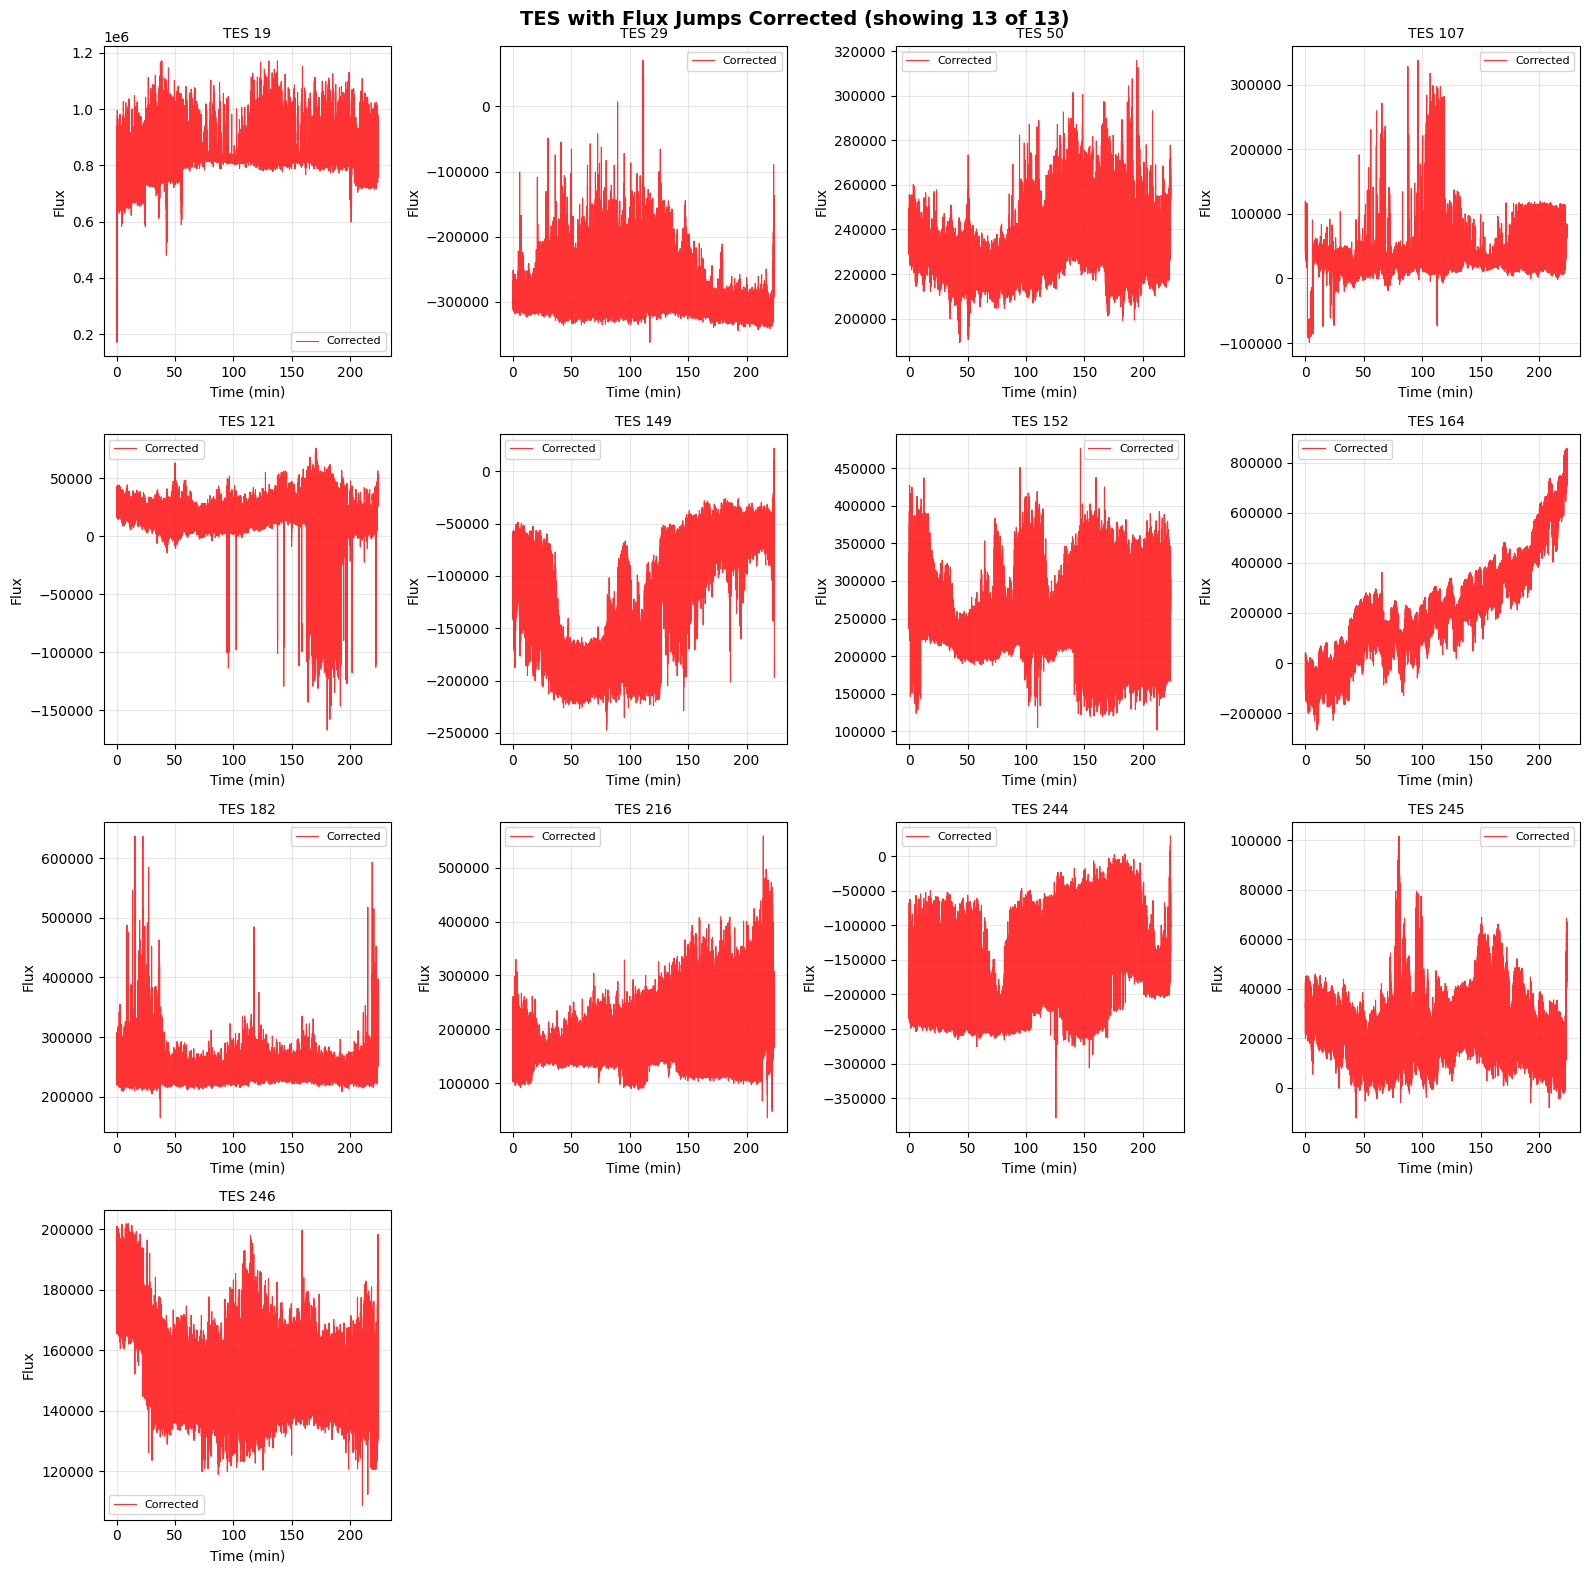

0

In [21]:
jr.plot_corrections(tt, todarray, results)

In [22]:
jr.save_results(results, output_dir=data_path + "year_23_day_2805_16.24.20", dataset_name="23_2805_16.24.20")

Saved pickle file to: ./day_2805_16.24.20/23_2805_16.24.20_results.pkl

All results saved to: ./day_2805_16.24.20
Total files saved: 1



['./day_2805_16.24.20/23_2805_16.24.20_results.pkl']